In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns
import torch

from datasets import load_dataset
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

In [3]:

df = pd.read_csv("GDPa1_v1.2_20250814.csv")
df

,antibody_id,antibody_name,Titer,Purity,SEC %Monomer,SMAC,HIC,HAC,PR_CHO,PR_Ova,...,hc_protein_sequence,hc_dna_sequence,vl_protein_sequence,lc_protein_sequence,lc_dna_sequence,hierarchical_cluster_fold,random_fold,hierarchical_cluster_IgG_isotype_stratified_fold,light_aligned_aho,heavy_aligned_aho
0,GDPa1-001,abagovomab,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,0.263108,...,MRAWIFFLLCLAGRALAQVKLQESGAELARPGASVKLSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,2,2,DIELTQSPASLSASVGETVTITCQAS--ENIY------SYLAWHQQ...,QVKLQES-GAELARPGASVKLSCKASG-YTFTN-----YWMQWVKQ...
1,GDPa1-002,abituzumab,193.31,99.825,97.620,2.745,2.545,3.690,0.205246,0.100155,...,MRAWIFFLLCLAGRALAQVQLQQSGGELAKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,4,0,DIQMTQSPSSLSASVGDRVTITCRAS--QDIS------NYLAWYQQ...,QVQLQQS-GGELAKPGASVKVSCKASG-YTFSS-----FWMHWVRQ...
2,GDPa1-003,abrezekimab,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,0.101180,...,MRAWIFFLLCLAGRALAQVTLKESGPVLVKPTETLTLTCTVSGFSL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,2,2,2,DIQMTQSPSSLSASVGDRVTITCLAS--EDIS------NYLAWYQQ...,QVTLKES-GPVLVKPTETLTLTCTVSG-FSLTN-----YHVQWIRQ...
3,GDPa1-004,abrilumab,327.32,98.575,98.605,2.715,2.565,1.005,0.000000,0.054971,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKVSGYTL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSVSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,3,0,DIQMTQSPSSVSASVGDRVTITCRAS--QGIS------SWLAWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKVSG-YTLSD-----LSIHWVRQ...
4,GDPa1-005,adalimumab,313.39,99.300,96.120,2.705,2.495,NaN,0.183387,0.085628,...,MRAWIFFLLCLAGRALAEVQLVESGGGLVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQGI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,2,0,DIQMTQSPSSLSASVGDRVTITCRAS--QGIR------NYLAWYQQ...,EVQLVES-GGGLVQPGRSLRLSCAASG-FTFDD-----YAMHWVRQ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,GDPa1-242,visilizumab,303.51,94.700,98.110,2.745,2.495,4.270,0.337537,0.338022,...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCSASSSVSYMNWYQQKPGKAPKRL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCSASSSV...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,1,0,DIQMTQSPSSLSASVGDRVTITCSAS--SSVS-------YMNWYQQ...,QVQLVQS-GAEVKKPGASVKVSCKASG-YTFIS-----YTMHWVRQ...
242,GDPa1-243,xentuzumab,281.21,98.970,99.875,10.000,4.500,NaN,0.178788,0.117684,...,MRAWIFFLLCLAGRALAQVELVESGGGLVQPGGSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIVLTQPPSVSGAPGQRVTISCSGSSSNIGSNSVSWYQQLPGTAPK...,MRAWIFFLLCLAGRALADIVLTQPPSVSGAPGQRVTISCSGSSSNI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,4,4,4,DIVLTQP-PSVSGAPGQRVTISCSGSS-SNIGS-----NSVSWYQQ...,QVELVES-GGGLVQPGGSLRLSCAASG-FTFTS-----YWMSWVRQ...
243,GDPa1-244,zalutumumab,266.55,89.430,98.065,2.705,2.590,3.760,0.000000,0.018385,...,MRAWIFFLLCLAGRALAQVQLVESGGGVVQPGRSLRLSCAASGFTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,AIQLTQSPSSLSASVGDRVTITCRASQDISSALVWYQQKPGKAPKL...,MRAWIFFLLCLAGRALAAIQLTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,0,0,0,AIQLTQSPSSLSASVGDRVTITCRAS--QDIS------SALVWYQQ...,QVQLVES-GGGVVQPGRSLRLSCAASG-FTFST-----YGMHWVRQ...
244,GDPa1-245,zanolimumab,301.96,99.115,97.780,2.725,2.660,3.730,0.400486,0.100804,...,MRAWI

Antibody isotypes can strongly influence some of the developability metrics, so they must be included as a feature in the model.

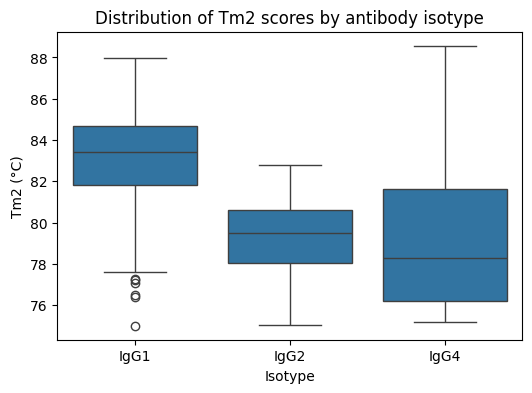

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(data = df, x = "hc_subtype", y = "Tm2")
plt.title("Distribution of Tm2 scores by antibody isotype")
plt.xlabel("Isotype")
plt.ylabel("Tm2 (°C)")
plt.show()

In [ ]:
# All developability metrics to evaluate
targets = ["Titer", "Purity", "SEC %Monomer", "SMAC", "HIC", "HAC", "PR_CHO", "PR_Ova", "Tm2", "AC-SINS_pH7.4"]

print("Missing values per target:")
print(df[targets].isna().sum())

# Keep a reference to the full dataframe (before any per-target dropna)
df_full = df.copy()


In [ ]:
model_name = "ollieturnbull/p-IgGen"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Paired sequence handling: Concatenate heavy and light chains and add beginning ("1") and end ("2") tokens
# (e.g. ["EVQLV...", "DIQMT..."] -> "1E V Q L V ... D I Q M T ... 2")
sequences = [
    "1" + " ".join(heavy) + " ".join(light) + "2"
    for heavy, light in zip(
        df_full["vh_protein_sequence"],
        df_full["vl_protein_sequence"],
    )
]

print(sequences[0])


In [ ]:
# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

batch_size = 16
mean_pooled_embeddings = []

for i in tqdm(range(0, len(sequences), batch_size)):
    batch = tokenizer(sequences[i:i+batch_size], return_tensors="pt", padding=True, truncation=True)
    outputs = model(batch["input_ids"].to(device), return_rep_layers=[-1], output_hidden_states=True)
    embeddings = outputs["hidden_states"][-1].detach().cpu().numpy()
    mean_pooled_embeddings.append(embeddings.mean(axis=1))

mean_pooled_embeddings = np.concatenate(mean_pooled_embeddings)
print(f"Embeddings shape: {mean_pooled_embeddings.shape}")


In [ ]:
# ── Random-split evaluation across all targets ──────────────────────────────
random_split_results = {}

for target in targets:
    # Drop rows where this target is missing; keep alignment with embeddings
    mask = df_full[target].notna().values
    X_t = mean_pooled_embeddings[mask]
    y_t = df_full.loc[mask, target].values

    if len(y_t) < 10:          # skip if too few samples
        random_split_results[target] = float("nan")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_t, y_t, test_size=0.2, random_state=42
    )

    lm = Ridge()
    lm.fit(X_train, y_train)
    y_pred = lm.predict(X_test)

    rho = spearmanr(y_pred, y_test).statistic
    random_split_results[target] = rho

    # Scatter plot
    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.title(f"Random split — {target}\nSpearman's ρ = {rho:.2f}")
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.tight_layout()
    plt.show()

print("\nRandom-split Spearman ρ summary:")
for t, r in random_split_results.items():
    print(f"  {t:<20s}  {r:.4f}" if not np.isnan(r) else f"  {t:<20s}  N/A")


In [ ]:
# ── Cross-validation (hierarchical cluster + IgG isotype stratified) ────────
fold_col = "hierarchical_cluster_IgG_isotype_stratified_fold"
cv_results = {}

for target in targets:
    # Drop rows where this target is missing; keep alignment with embeddings
    mask = df_full[target].notna().values
    X_t    = mean_pooled_embeddings[mask]
    y_t    = df_full.loc[mask, target].to_numpy(dtype=float)
    folds_t = df_full.loc[mask, fold_col].to_numpy()

    if len(y_t) < 10:
        cv_results[target] = float("nan")
        continue

    unique_folds = [f for f in np.unique(folds_t) if f == f]  # drop NaN

    per_fold_stats = []
    y_pred_all = np.full(len(y_t), np.nan)
    y_true_all = np.full(len(y_t), np.nan)

    for f in unique_folds:
        test_idx  = np.where(folds_t == f)[0]
        train_idx = np.where(folds_t != f)[0]

        X_train, y_train = X_t[train_idx], y_t[train_idx]
        X_test,  y_test  = X_t[test_idx],  y_t[test_idx]

        lm = Ridge()
        lm.fit(X_train, y_train)
        y_pred = lm.predict(X_test)

        y_pred_all[test_idx] = y_pred
        y_true_all[test_idx] = y_test

        rho = spearmanr(y_test, y_pred).statistic
        per_fold_stats.append((int(f), rho, len(y_test)))

    valid = ~np.isnan(y_true_all)
    overall_rho = spearmanr(y_true_all[valid], y_pred_all[valid]).statistic
    cv_results[target] = overall_rho

    print(f"\n── {target} ──")
    print("Fold\tN\tSpearman_rho")
    for f, rho, n in per_fold_stats:
        print(f"{f}\t{n}\t{rho:.4f}")
    print(f"Overall (all folds)\t{valid.sum()}\t{overall_rho:.4f}")

    plt.figure()
    plt.scatter(y_true_all[valid], y_pred_all[valid], alpha=0.7)
    plt.title(f"Ridge CV ({fold_col}) — {target}\nOverall Spearman: {overall_rho:.3f}")
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Target": list(targets),
    "Random-split Spearman ρ": [random_split_results.get(t, float("nan")) for t in targets],
    "CV Spearman ρ": [cv_results.get(t, float("nan")) for t in targets],
})
summary = summary.round(4)
print(summary.to_string(index=False))
summary
